In [1]:
import pandas as pd
import numpy as np
import os
import glob
import gc
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configuration
RAW_DATA_DIR = '/opt/work/dataset/raw'
OUTPUT_DIR = '/opt/work/dataset/processed'
CHUNK_SIZE = 50000  # Process 50K rows at a time
RANDOM_STATE = 42

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Chunk size: {CHUNK_SIZE:,} rows")

Raw data directory: /opt/work/dataset/raw
Output directory: /opt/work/dataset/processed
Chunk size: 50,000 rows


In [3]:
# Find all CSV files
csv_files = sorted(glob.glob(os.path.join(RAW_DATA_DIR, '*.csv')))

print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"  - {os.path.basename(f)} ({size_mb:.1f} MB)")

Found 10 CSV files:
  - Friday-02-03-2018_TrafficForML_CICFlowMeter.csv (336.0 MB)
  - Friday-16-02-2018_TrafficForML_CICFlowMeter.csv (318.3 MB)
  - Friday-23-02-2018_TrafficForML_CICFlowMeter.csv (365.1 MB)
  - Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv (3867.1 MB)
  - Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv (102.8 MB)
  - Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv (358.5 MB)
  - Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv (364.9 MB)
  - Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv (341.6 MB)
  - Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv (313.7 MB)
  - Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv (199.6 MB)


In [5]:
# Load first file to inspect structure
print("\nInspecting first CSV file...")
sample_df = pd.read_csv(csv_files[0], nrows=1000)

print(f"\nShape: {sample_df.shape}")
print(f"Columns: {len(sample_df.columns)}")
print(f"\nColumn names:")
for i, col in enumerate(sample_df.columns):
    print(f"  {i+1}. {col}")


Inspecting first CSV file...

Shape: (1000, 80)
Columns: 80

Column names:
  1. Dst Port
  2. Protocol
  3. Timestamp
  4. Flow Duration
  5. Tot Fwd Pkts
  6. Tot Bwd Pkts
  7. TotLen Fwd Pkts
  8. TotLen Bwd Pkts
  9. Fwd Pkt Len Max
  10. Fwd Pkt Len Min
  11. Fwd Pkt Len Mean
  12. Fwd Pkt Len Std
  13. Bwd Pkt Len Max
  14. Bwd Pkt Len Min
  15. Bwd Pkt Len Mean
  16. Bwd Pkt Len Std
  17. Flow Byts/s
  18. Flow Pkts/s
  19. Flow IAT Mean
  20. Flow IAT Std
  21. Flow IAT Max
  22. Flow IAT Min
  23. Fwd IAT Tot
  24. Fwd IAT Mean
  25. Fwd IAT Std
  26. Fwd IAT Max
  27. Fwd IAT Min
  28. Bwd IAT Tot
  29. Bwd IAT Mean
  30. Bwd IAT Std
  31. Bwd IAT Max
  32. Bwd IAT Min
  33. Fwd PSH Flags
  34. Bwd PSH Flags
  35. Fwd URG Flags
  36. Bwd URG Flags
  37. Fwd Header Len
  38. Bwd Header Len
  39. Fwd Pkts/s
  40. Bwd Pkts/s
  41. Pkt Len Min
  42. Pkt Len Max
  43. Pkt Len Mean
  44. Pkt Len Std
  45. Pkt Len Var
  46. FIN Flag Cnt
  47. SYN Flag Cnt
  48. RST Flag Cnt
  49. PS

In [6]:
# Show data types (everything will be object/string initially)
print("\nData types:")
print(sample_df.dtypes.value_counts())

print("\nFirst few rows:")
sample_df.head()


Data types:
int64      42
float64    36
object      2
Name: count, dtype: int64

First few rows:


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,02/03/2018 08:47:38,141385,9,7,553,3773,202,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,49684,6,02/03/2018 08:47:38,281,2,1,38,0,38,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,443,6,02/03/2018 08:47:40,279824,11,15,1086,10527,385,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,443,6,02/03/2018 08:47:40,132,2,0,0,0,0,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,443,6,02/03/2018 08:47:41,274016,9,13,1285,6141,517,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [14]:
# Identify label column
label_col = "Label"

# Show unique labels
print(f"\nUnique labels in sample:")
print(sample_df[label_col].value_counts())

# Identify non-feature columns to exclude from numeric conversion
non_numeric_cols = [label_col, "Timestamp"]

# Feature columns = everything except Label (we can later drop Timestamp if we want)
feature_cols = [c for c in sample_df.columns if c != label_col]

# Numeric feature columns = feature cols excluding Timestamp
numeric_feature_cols = [c for c in feature_cols if c != "Timestamp"]

print("Label:", label_col)
print("Numeric features:", len(numeric_feature_cols))
print("Non-numeric excluded:", non_numeric_cols)


Unique labels in sample:
Label
Benign    1000
Name: count, dtype: int64
Label: Label
Numeric features: 78
Non-numeric excluded: ['Label', 'Timestamp']


In [15]:
# Cell: Numeric conversion + NaN / Inf handling (Timestamp preserved)

def clean_numeric_features(df, numeric_cols):
    df = df.copy()

    # Convert numeric columns safely
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Replace inf/-inf with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    return df


# Apply to sample to validate
sample_numeric_clean = clean_numeric_features(sample_df, numeric_feature_cols)

print("Before cleaning:")
print(sample_df[numeric_feature_cols].isna().sum().sum(), "NaNs")

print("\nAfter cleaning:")
print(sample_numeric_clean[numeric_feature_cols].isna().sum().sum(), "NaNs")

print("\nDtypes check:")
print(sample_numeric_clean.dtypes.value_counts())

Before cleaning:
19 NaNs

After cleaning:
52 NaNs

Dtypes check:
int64      42
float64    36
object      2
Name: count, dtype: int64


In [16]:
# Cell: Median imputation on numeric features (Timestamp/Label preserved)

def impute_median(df, numeric_cols):
    df = df.copy()
    
    # Column-wise medians on numeric columns only
    medians = df[numeric_cols].median(numeric_only=True)
    
    # Fill NaNs with median
    df[numeric_cols] = df[numeric_cols].fillna(medians)
    
    # If any column is still NaN (happens if entire column is NaN), fill with 0
    df[numeric_cols] = df[numeric_cols].fillna(0)
    
    return df

# Apply on the sample-cleaned df (the one after numeric conversion)
sample_imputed = impute_median(sample_numeric_clean, numeric_feature_cols)

print("NaNs after median imputation (numeric only):",
      sample_imputed[numeric_feature_cols].isna().sum().sum())

# Quick sanity checks
print("\nTimestamp still object?:", sample_imputed["Timestamp"].dtype)
print("Label still object?:", sample_imputed["Label"].dtype)

# Show a few rows
sample_imputed.head()

NaNs after median imputation (numeric only): 0

Timestamp still object?: object
Label still object?: object


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,02/03/2018 08:47:38,141385,9,7,553,3773,202,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,49684,6,02/03/2018 08:47:38,281,2,1,38,0,38,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,443,6,02/03/2018 08:47:40,279824,11,15,1086,10527,385,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,443,6,02/03/2018 08:47:40,132,2,0,0,0,0,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,443,6,02/03/2018 08:47:41,274016,9,13,1285,6141,517,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [17]:
# Scan all files to find all unique labels
print("Scanning all files for unique labels...\n")

all_labels = set()

for csv_file in csv_files:
    print(f"  Scanning: {os.path.basename(csv_file)}")
    # Read in chunks to save memory
    for chunk in pd.read_csv(csv_file, chunksize=10000, usecols=[label_col]):
        all_labels.update(chunk[label_col].unique())

all_labels = sorted(list(all_labels))

print(f"\nFound {len(all_labels)} unique labels across all files:")
for i, label in enumerate(all_labels):
    print(f"  {i}. {label}")

Scanning all files for unique labels...

  Scanning: Friday-02-03-2018_TrafficForML_CICFlowMeter.csv
  Scanning: Friday-16-02-2018_TrafficForML_CICFlowMeter.csv
  Scanning: Friday-23-02-2018_TrafficForML_CICFlowMeter.csv
  Scanning: Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv
  Scanning: Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv
  Scanning: Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv
  Scanning: Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv
  Scanning: Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv
  Scanning: Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv
  Scanning: Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv

Found 16 unique labels across all files:
  0. Benign
  1. Bot
  2. Brute Force -Web
  3. Brute Force -XSS
  4. DDOS attack-HOIC
  5. DDOS attack-LOIC-UDP
  6. DDoS attacks-LOIC-HTTP
  7. DoS attacks-GoldenEye
  8. DoS attacks-Hulk
  9. DoS attacks-SlowHTTPTest
  10. DoS attacks-Slowloris
  11. FTP-BruteForce
  12. Infilteration
  13. Label

In [18]:
# Find which file contains the bad "Label" rows

bad_value = "Label"
bad_rows_info = []

for csv_file in csv_files:
    bad_count = 0
    for chunk in pd.read_csv(csv_file, chunksize=100000, usecols=[label_col]):
        bad_count += (chunk[label_col] == bad_value).sum()
    if bad_count > 0:
        bad_rows_info.append((os.path.basename(csv_file), int(bad_count)))

print("Files containing bad label value 'Label':")
for fname, cnt in bad_rows_info:
    print(f"  - {fname}: {cnt} rows")

Files containing bad label value 'Label':
  - Friday-16-02-2018_TrafficForML_CICFlowMeter.csv: 1 rows
  - Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv: 25 rows
  - Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv: 33 rows


In [20]:
 # Cell: Chunk processing -> clean -> impute -> filter junk labels -> write Parquet

PARQUET_BASE = os.path.join(OUTPUT_DIR, "parquet_by_file")
os.makedirs(PARQUET_BASE, exist_ok=True)

BAD_LABEL_VALUE = "Label"

def preprocess_chunk(chunk):
    # Basic string cleanup on Label
    chunk[label_col] = chunk[label_col].astype(str).str.strip()

    # Remove junk header rows
    chunk = chunk[chunk[label_col] != BAD_LABEL_VALUE]

    # 1) convert numeric cols + handle inf
    chunk = clean_numeric_features(chunk, numeric_feature_cols)

    # 2) impute numeric NaNs
    chunk = impute_median(chunk, numeric_feature_cols)

    # Keep Timestamp as-is for now (string); we’ll parse later globally if needed
    return chunk

total_rows_written = 0
start_time = time.time()

for csv_file in csv_files:
    file_name = os.path.basename(csv_file)
    file_stem = os.path.splitext(file_name)[0]
    out_dir = os.path.join(PARQUET_BASE, file_stem)
    os.makedirs(out_dir, exist_ok=True)

    print(f"\nProcessing {file_name}")
    file_rows_written = 0
    chunk_idx = 0

    # Read full rows (all columns)
    for chunk in pd.read_csv(csv_file, chunksize=CHUNK_SIZE):
        chunk_idx += 1

        # preprocess
        chunk = preprocess_chunk(chunk)

        # Write chunk parquet
        out_path = os.path.join(out_dir, f"part_{chunk_idx:05d}.parquet")
        chunk.to_parquet(out_path, index=False)

        file_rows_written += len(chunk)
        total_rows_written += len(chunk)

        # light memory cleanup
        del chunk
        gc.collect()

        if chunk_idx % 20 == 0:
            elapsed = time.time() - start_time
            print(f"chunks: {chunk_idx}, file rows: {file_rows_written:,}, total: {total_rows_written:,}, elapsed: {elapsed/60:.1f} min")

    print(f"Done {file_name} → wrote {file_rows_written:,} rows to {out_dir}")

elapsed_total = time.time() - start_time
print(f"\nAll files processed. Total rows written: {total_rows_written:,}")
print(f"⏱ Total time: {elapsed_total/60:.1f} minutes")


Processing Friday-02-03-2018_TrafficForML_CICFlowMeter.csv
chunks: 20, file rows: 1,000,000, total: 1,000,000, elapsed: 0.1 min
Done Friday-02-03-2018_TrafficForML_CICFlowMeter.csv → wrote 1,048,575 rows to /opt/work/dataset/processed/parquet_by_file/Friday-02-03-2018_TrafficForML_CICFlowMeter

Processing Friday-16-02-2018_TrafficForML_CICFlowMeter.csv
chunks: 20, file rows: 999,999, total: 2,048,574, elapsed: 0.2 min
Done Friday-16-02-2018_TrafficForML_CICFlowMeter.csv → wrote 1,048,574 rows to /opt/work/dataset/processed/parquet_by_file/Friday-16-02-2018_TrafficForML_CICFlowMeter

Processing Friday-23-02-2018_TrafficForML_CICFlowMeter.csv
chunks: 20, file rows: 1,000,000, total: 3,097,149, elapsed: 0.4 min
Done Friday-23-02-2018_TrafficForML_CICFlowMeter.csv → wrote 1,048,575 rows to /opt/work/dataset/processed/parquet_by_file/Friday-23-02-2018_TrafficForML_CICFlowMeter

Processing Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv
chunks: 20, file rows: 1,000,000, total: 4,145,724, 

In [22]:
# Cell: Merge Parquets with schema normalization

import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc

MERGED_DIR = os.path.join(OUTPUT_DIR, "parquet_merged")
os.makedirs(MERGED_DIR, exist_ok=True)

parquet_files = sorted(glob.glob(os.path.join(PARQUET_BASE, "*", "*.parquet")))
print(f"Found {len(parquet_files)} parquet part files")

# Read schema from first file
first = pq.read_table(parquet_files[0])
cols = first.schema.names

# Decide target schema:
# - keep Timestamp as string
# - keep Label as string (encode later)
# - EVERYTHING else -> float64
target_fields = []
for c in cols:
    if c in ["Timestamp", "Label"]:
        target_fields.append(pa.field(c, pa.string()))
    else:
        target_fields.append(pa.field(c, pa.float64()))

target_schema = pa.schema(target_fields)
print("Target schema ready (numeric -> float64, Timestamp/Label -> string)")

def normalize_table(tbl: pa.Table) -> pa.Table:
    arrays = []
    for field in target_schema:
        name = field.name
        arr = tbl[name]

        if name in ["Timestamp", "Label"]:
            # force string
            if not pa.types.is_string(arr.type):
                arr = pc.cast(arr, pa.string(), safe=False)
        else:
            # force float64 for all numerics
            if not pa.types.is_float64(arr.type):
                arr = pc.cast(arr, pa.float64(), safe=False)

        arrays.append(arr)

    return pa.Table.from_arrays(arrays, schema=target_schema)

merged_count = 0
file_idx = 0
BATCH_FILES = 20  # increase later if RAM allows
start_time = time.time()

while file_idx < len(parquet_files):
    batch_paths = parquet_files[file_idx:file_idx + BATCH_FILES]
    tables = []

    for p in batch_paths:
        t = pq.read_table(p)
        t = normalize_table(t)
        tables.append(t)

    combined = pa.concat_tables(tables, promote=True)
    merged_count += combined.num_rows

    out_path = os.path.join(MERGED_DIR, f"part_{file_idx//BATCH_FILES + 1:06d}.parquet")
    pq.write_table(combined, out_path)

    elapsed = (time.time() - start_time) / 60
    print(f"Wrote {os.path.basename(out_path)} | rows: {combined.num_rows:,} | total merged: {merged_count:,} | {elapsed:.1f} min")

    del tables, combined
    gc.collect()
    file_idx += BATCH_FILES

print(f"\nMerge complete. Total rows merged: {merged_count:,}")
print(f"Merged dataset at: {MERGED_DIR}")

Found 326 parquet part files
Target schema ready (numeric -> float64, Timestamp/Label -> string)
Wrote part_000001.parquet | rows: 1,000,000 | total merged: 1,000,000 | 0.1 min
Wrote part_000002.parquet | rows: 998,575 | total merged: 1,998,575 | 0.1 min
Wrote part_000003.parquet | rows: 998,574 | total merged: 2,997,149 | 0.2 min
Wrote part_000004.parquet | rows: 998,575 | total merged: 3,995,724 | 0.2 min
Wrote part_000005.parquet | rows: 1,000,000 | total merged: 4,995,724 | 0.2 min
Wrote part_000006.parquet | rows: 1,000,000 | total merged: 5,995,724 | 0.3 min
Wrote part_000007.parquet | rows: 1,000,000 | total merged: 6,995,724 | 0.4 min
Wrote part_000008.parquet | rows: 1,000,000 | total merged: 7,995,724 | 0.4 min
Wrote part_000009.parquet | rows: 1,000,000 | total merged: 8,995,724 | 0.5 min
Wrote part_000010.parquet | rows: 1,000,000 | total merged: 9,995,724 | 0.5 min
Wrote part_000011.parquet | rows: 1,000,000 | total merged: 10,995,724 | 0.6 min
Wrote part_000012.parquet | 

In [23]:
# Identify zero-value (all-zero) columns across the FULL merged dataset

import pyarrow.parquet as pq
import pyarrow.compute as pc
import pyarrow as pa
import numpy as np
import os, glob
from collections import defaultdict

MERGED_DIR = "/opt/work/dataset/processed/parquet_merged"
merged_parts = sorted(glob.glob(os.path.join(MERGED_DIR, "part_*.parquet")))
print(f"Found {len(merged_parts)} merged parquet parts")

# Read schema from first part
t0 = pq.read_table(merged_parts[0], columns=None)
all_cols = t0.schema.names

# Columns to exclude from zero-check
exclude_cols = {"Label", "Timestamp"}   # keep timestamp, don't treat as numeric feature

numeric_cols = [c for c in all_cols if c not in exclude_cols]
print(f"Numeric columns to check: {len(numeric_cols)}")

# Track global min/max per column
global_min = {c: np.inf for c in numeric_cols}
global_max = {c: -np.inf for c in numeric_cols}

# Process each parquet part
for i, p in enumerate(merged_parts, 1):
    tbl = pq.read_table(p, columns=numeric_cols)

    for c in numeric_cols:
        arr = tbl[c]

        # drop nulls
        arr = pc.drop_null(arr)

        if arr.num_chunks == 0 or arr.length() == 0:
            continue

        # compute min/max per file for this column
        mn = pc.min(arr).as_py()
        mx = pc.max(arr).as_py()

        if mn is not None and mn < global_min[c]:
            global_min[c] = mn
        if mx is not None and mx > global_max[c]:
            global_max[c] = mx

    if i % 2 == 0 or i == len(merged_parts):
        print(f"Processed {i}/{len(merged_parts)} parts")

# Identify all-zero columns
zero_cols = [c for c in numeric_cols if global_min[c] == 0.0 and global_max[c] == 0.0]

print(f"\nColumns with all zeros ({len(zero_cols)}):")
for c in zero_cols:
    print(" -", c)

# Save list for later reuse
ZERO_COLS_PATH = "/opt/work/dataset/processed/zero_cols.txt"
with open(ZERO_COLS_PATH, "w") as f:
    for c in zero_cols:
        f.write(c + "\n")

print(f"\nSaved zero columns list to: {ZERO_COLS_PATH}")

Found 17 merged parquet parts
Numeric columns to check: 78
Processed 2/17 parts
Processed 4/17 parts
Processed 6/17 parts
Processed 8/17 parts
Processed 10/17 parts
Processed 12/17 parts
Processed 14/17 parts
Processed 16/17 parts
Processed 17/17 parts

Columns with all zeros (8):
 - Bwd PSH Flags
 - Bwd URG Flags
 - Fwd Byts/b Avg
 - Fwd Pkts/b Avg
 - Fwd Blk Rate Avg
 - Bwd Byts/b Avg
 - Bwd Pkts/b Avg
 - Bwd Blk Rate Avg

Saved zero columns list to: /opt/work/dataset/processed/zero_cols.txt


In [24]:
# Remove bad-rows and zero-only columns

import pyarrow.parquet as pq
import pyarrow as pa

MERGED_DIR = "/opt/work/dataset/processed/parquet_merged"
CLEAN_DIR = "/opt/work/dataset/processed/parquet_clean"
ZERO_COLS_PATH = "/opt/work/dataset/processed/zero_cols.txt"

os.makedirs(CLEAN_DIR, exist_ok=True)

# Load zero-only columns
with open(ZERO_COLS_PATH) as f:
    zero_cols = [c.strip() for c in f.readlines()]

print("Zero-only columns to drop:", zero_cols)

total_rows = 0
written_rows = 0

for file in sorted(os.listdir(MERGED_DIR)):
    if not file.endswith(".parquet"):
        continue

    path = os.path.join(MERGED_DIR, file)
    table = pq.read_table(path)

    df = table.to_pandas()

    before = len(df)

    # Drop bad label rows
    df = df[df["Label"] != "Label"]

    # Drop zero-only columns
    df = df.drop(columns=zero_cols)

    after = len(df)

    out_path = os.path.join(CLEAN_DIR, file)
    df.to_parquet(out_path, index=False)

    total_rows += before
    written_rows += after

    print(f"{file}: {before:,} → {after:,}")

print(f"\nCleaned rows written: {written_rows:,} / {total_rows:,}")
print(f"Output: {CLEAN_DIR}")

Zero-only columns to drop: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
part_000001.parquet: 1,000,000 → 1,000,000
part_000002.parquet: 998,575 → 998,575
part_000003.parquet: 998,574 → 998,574
part_000004.parquet: 998,575 → 998,575
part_000005.parquet: 1,000,000 → 1,000,000
part_000006.parquet: 1,000,000 → 1,000,000
part_000007.parquet: 1,000,000 → 1,000,000
part_000008.parquet: 1,000,000 → 1,000,000
part_000009.parquet: 1,000,000 → 1,000,000
part_000010.parquet: 1,000,000 → 1,000,000
part_000011.parquet: 1,000,000 → 1,000,000
part_000012.parquet: 979,848 → 979,848
part_000013.parquet: 998,575 → 998,575
part_000014.parquet: 998,575 → 998,575
part_000015.parquet: 998,575 → 998,575
part_000016.parquet: 998,559 → 998,559
part_000017.parquet: 263,087 → 263,087

Cleaned rows written: 16,232,943 / 16,232,943
Output: /opt/work/dataset/processed/parquet_clean


In [25]:
import pandas as pd
import os
from collections import Counter

CLEAN_DIR = "/opt/work/dataset/processed/parquet_clean"

# Load only Label column from all parquet files
labels = []

for file in sorted(os.listdir(CLEAN_DIR)):
    if not file.endswith(".parquet"):
        continue

    path = os.path.join(CLEAN_DIR, file)
    df = pd.read_parquet(path, columns=["Label"])
    labels.extend(df["Label"].tolist())

labels = pd.Series(labels)

print(f"Total samples: {len(labels):,}")

# Encode labels
label_classes = sorted(labels.unique())
label_to_id = {label: idx for idx, label in enumerate(label_classes)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

encoded = labels.map(label_to_id)

# Distribution
counts = encoded.value_counts().sort_index()
percentages = (counts / counts.sum()) * 100

dist_df = pd.DataFrame({
    "Label": [id_to_label[i] for i in counts.index],
    "Count": counts.values,
    "Percentage": percentages.round(3).values
})

print("\nClass distribution:")
print(dist_df)

# Save mapping + distribution
dist_df.to_csv("/opt/work/dataset/processed/class_distribution.csv", index=False)

with open("/opt/work/dataset/processed/label_mapping.txt", "w") as f:
    for k, v in label_to_id.items():
        f.write(f"{v}: {k}\n")

print("\nSaved:")
print(" - class_distribution.csv")
print(" - label_mapping.txt")

Total samples: 16,232,943

Class distribution:
                       Label     Count  Percentage
0                     Benign  13484708      83.070
1                        Bot    286191       1.763
2           Brute Force -Web       611       0.004
3           Brute Force -XSS       230       0.001
4           DDOS attack-HOIC    686012       4.226
5       DDOS attack-LOIC-UDP      1730       0.011
6     DDoS attacks-LOIC-HTTP    576191       3.550
7      DoS attacks-GoldenEye     41508       0.256
8           DoS attacks-Hulk    461912       2.846
9   DoS attacks-SlowHTTPTest    139890       0.862
10     DoS attacks-Slowloris     10990       0.068
11            FTP-BruteForce    193360       1.191
12             Infilteration    161934       0.998
13             SQL Injection        87       0.001
14            SSH-Bruteforce    187589       1.156

Saved:
 - class_distribution.csv
 - label_mapping.txt


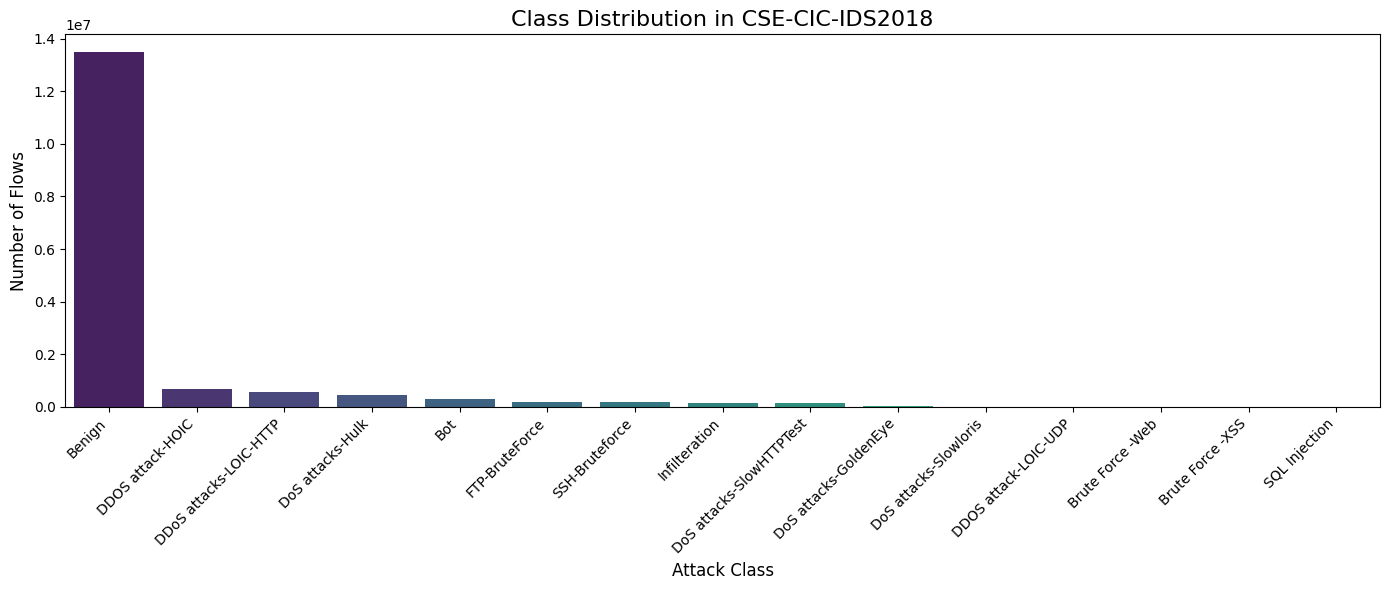

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load distribution
dist_path = "/opt/work/dataset/processed/class_distribution.csv"
dist_df = pd.read_csv(dist_path)

# Sort by count (descending)
dist_df = dist_df.sort_values("Count", ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(
    x="Label",
    y="Count",
    data=dist_df,
    palette="viridis"
)

plt.title("Class Distribution in CSE-CIC-IDS2018", fontsize=16)
plt.xlabel("Attack Class", fontsize=12)
plt.ylabel("Number of Flows", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

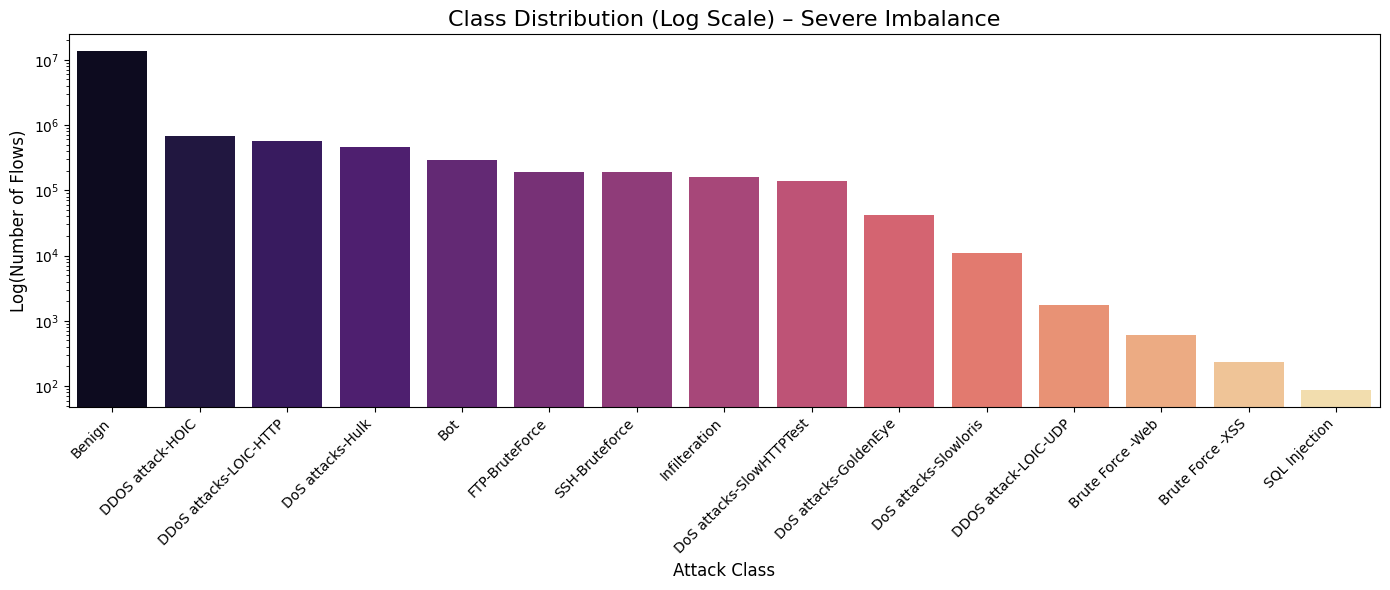

In [27]:
plt.figure(figsize=(14, 6))
sns.barplot(
    x="Label",
    y="Count",
    data=dist_df,
    palette="magma"
)

plt.yscale("log")
plt.title("Class Distribution (Log Scale) – Severe Imbalance", fontsize=16)
plt.xlabel("Attack Class", fontsize=12)
plt.ylabel("Log(Number of Flows)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [1]:
import pandas as pd
import os
import numpy as np

CLEAN_DIR = "/opt/work/dataset/processed/parquet_clean"
BALANCED_DIR = "/opt/work/dataset/processed/parquet_balanced"
os.makedirs(BALANCED_DIR, exist_ok=True)

TARGET_BENIGN = 3_000_000  # paper-faithful downsampling

benign_collected = 0
total_written = 0

print("Starting balancing...\n")

for file in sorted(os.listdir(CLEAN_DIR)):
    if not file.endswith(".parquet"):
        continue

    path = os.path.join(CLEAN_DIR, file)
    df = pd.read_parquet(path)

    benign_df = df[df["Label"] == "Benign"]
    attack_df = df[df["Label"] != "Benign"]

    # Downsample benign if needed
    if benign_collected < TARGET_BENIGN:
        remaining = TARGET_BENIGN - benign_collected
        if len(benign_df) > remaining:
            benign_df = benign_df.sample(remaining, random_state=42)
        benign_collected += len(benign_df)
    else:
        benign_df = benign_df.iloc[0:0]  # drop remaining benign

    balanced_df = pd.concat([benign_df, attack_df], axis=0)

    if len(balanced_df) == 0:
        continue

    out_path = os.path.join(BALANCED_DIR, file)
    balanced_df.to_parquet(out_path, index=False)

    total_written += len(balanced_df)

    print(
        f"{file}: "
        f"Benign kept={len(benign_df):,}, "
        f"Attacks kept={len(attack_df):,}, "
        f"Total written={total_written:,}"
    )

print("\nBalancing complete")
print(f"Final dataset size ≈ {total_written:,}")
print(f"Benign capped at {benign_collected:,}")

Starting balancing...

part_000001.parquet: Benign kept=713,809, Attacks kept=286,191, Total written=1,000,000
part_000002.parquet: Benign kept=470,201, Attacks kept=528,374, Total written=1,998,575
part_000003.parquet: Benign kept=924,580, Attacks kept=73,994, Total written=2,997,149
part_000004.parquet: Benign kept=422,384, Attacks kept=576,191, Total written=3,995,724
part_000005.parquet: Benign kept=469,026, Attacks kept=0, Total written=4,464,750
part_000012.parquet: Benign kept=0, Attacks kept=145,561, Total written=4,610,311
part_000013.parquet: Benign kept=0, Attacks kept=362, Total written=4,610,673
part_000014.parquet: Benign kept=0, Attacks kept=380,949, Total written=4,991,622
part_000015.parquet: Benign kept=0, Attacks kept=363,228, Total written=5,354,850
part_000016.parquet: Benign kept=0, Attacks kept=324,514, Total written=5,679,364
part_000017.parquet: Benign kept=0, Attacks kept=68,871, Total written=5,748,235

Balancing complete
Final dataset size ≈ 5,748,235
Benign

Reading balanced dataset for class distribution...

Balanced class distribution:
                       Label    Count  Percentage
0                     Benign  3000000      52.190
1           DDOS attack-HOIC   686012      11.934
2     DDoS attacks-LOIC-HTTP   576191      10.024
3           DoS attacks-Hulk   461912       8.036
4                        Bot   286191       4.979
5             FTP-BruteForce   193360       3.364
6             SSH-Bruteforce   187589       3.263
7              Infilteration   161934       2.817
8   DoS attacks-SlowHTTPTest   139890       2.434
9      DoS attacks-GoldenEye    41508       0.722
10     DoS attacks-Slowloris    10990       0.191
11      DDOS attack-LOIC-UDP     1730       0.030
12          Brute Force -Web      611       0.011
13          Brute Force -XSS      230       0.004
14             SQL Injection       87       0.002

Saved distribution table to: /opt/work/dataset/processed/balanced_class_distribution.csv


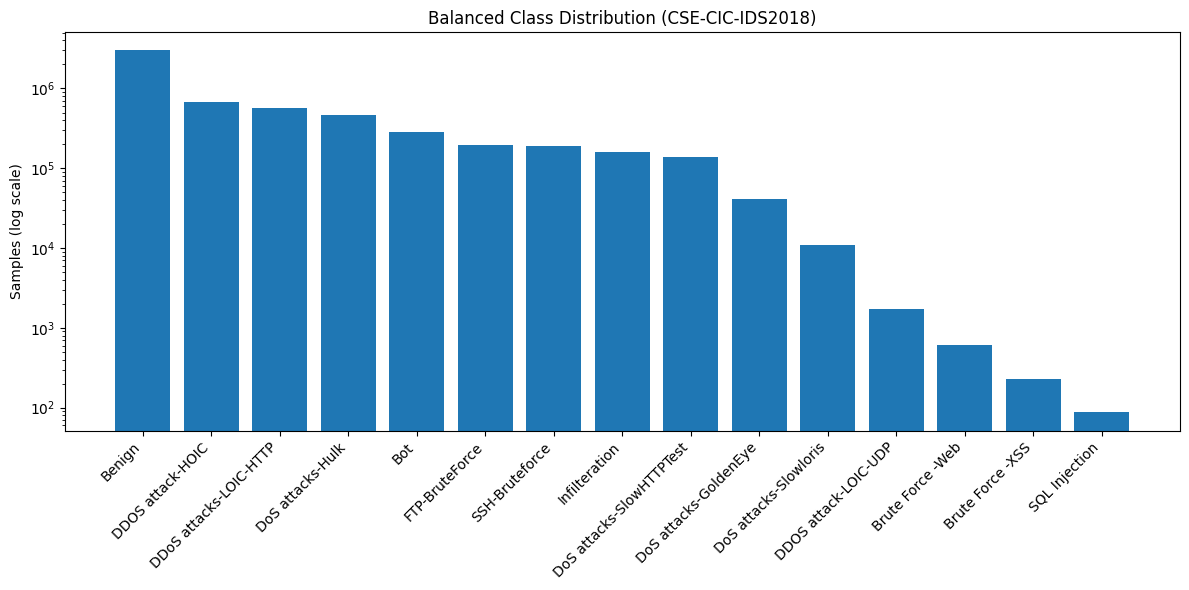

Saved plot to: /opt/work/dataset/processed/balanced_class_distribution.png


In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt

BALANCED_DIR = "/opt/work/dataset/processed/parquet_balanced"

print("Reading balanced dataset for class distribution...\n")

label_counts = {}

for file in sorted(os.listdir(BALANCED_DIR)):
    if not file.endswith(".parquet"):
        continue
    df = pd.read_parquet(os.path.join(BALANCED_DIR, file), columns=["Label"])
    counts = df["Label"].value_counts()
    for label, cnt in counts.items():
        label_counts[label] = label_counts.get(label, 0) + cnt

dist_df = (
    pd.DataFrame(label_counts.items(), columns=["Label", "Count"])
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

total = dist_df["Count"].sum()
dist_df["Percentage"] = (dist_df["Count"] / total * 100).round(3)

print("Balanced class distribution:")
print(dist_df)

# Save table
out_csv = "/opt/work/dataset/processed/balanced_class_distribution.csv"
dist_df.to_csv(out_csv, index=False)
print(f"\nSaved distribution table to: {out_csv}")

# Plot
plt.figure(figsize=(12, 6))
plt.bar(dist_df["Label"], dist_df["Count"])
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Samples (log scale)")
plt.title("Balanced Class Distribution (CSE-CIC-IDS2018)")
plt.tight_layout()

plot_path = "/opt/work/dataset/processed/balanced_class_distribution.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print(f"Saved plot to: {plot_path}")

In [3]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import os
import pickle

BALANCED_DIR = "/opt/work/dataset/processed/parquet_balanced"
ENCODED_DIR = "/opt/work/dataset/processed/parquet_encoded"
os.makedirs(ENCODED_DIR, exist_ok=True)

# Fit encoder on all labels
labels = []

for file in os.listdir(BALANCED_DIR):
    if file.endswith(".parquet"):
        df = pd.read_parquet(os.path.join(BALANCED_DIR, file), columns=["Label"])
        labels.extend(df["Label"].values)

le = LabelEncoder()
le.fit(labels)

print("Label encoding mapping:")
for i, cls in enumerate(le.classes_):
    print(f"{i}: {cls}")

# Save encoder
with open("/opt/work/dataset/processed/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

# Apply encoding file by file
total = 0
for file in sorted(os.listdir(BALANCED_DIR)):
    if not file.endswith(".parquet"):
        continue

    df = pd.read_parquet(os.path.join(BALANCED_DIR, file))
    df["Label"] = le.transform(df["Label"])

    out_path = os.path.join(ENCODED_DIR, file)
    df.to_parquet(out_path, index=False)

    total += len(df)

print(f"\nEncoded dataset written. Total samples: {total:,}")
print(f"Saved encoder to label_encoder.pkl")

Label encoding mapping:
0: Benign
1: Bot
2: Brute Force -Web
3: Brute Force -XSS
4: DDOS attack-HOIC
5: DDOS attack-LOIC-UDP
6: DDoS attacks-LOIC-HTTP
7: DoS attacks-GoldenEye
8: DoS attacks-Hulk
9: DoS attacks-SlowHTTPTest
10: DoS attacks-Slowloris
11: FTP-BruteForce
12: Infilteration
13: SQL Injection
14: SSH-Bruteforce

Encoded dataset written. Total samples: 5,748,235
Saved encoder to label_encoder.pkl


In [3]:
import pandas as pd
import os

ENCODED_DIR = "/opt/work/dataset/processed/parquet_encoded"
TIME_DIR = "/opt/work/dataset/processed/parquet_timestamp_numeric"

os.makedirs(TIME_DIR, exist_ok=True)

total = 0

for file in sorted(os.listdir(ENCODED_DIR)):
    if not file.endswith(".parquet"):
        continue

    df = pd.read_parquet(os.path.join(ENCODED_DIR, file))

    ## Parse timestamp (CIC format is dd/mm/yyyy ...)
    df["Timestamp"] = pd.to_datetime(
        df["Timestamp"],
        format="%d/%m/%Y %H:%M:%S",
        errors="coerce"
    )
    
    df = df.dropna(subset=["Timestamp"])
    
    # keep Timestamp as a single numeric feature
    df["Timestamp"] = (df["Timestamp"].astype("int64") // 10**9).astype("float64")
    
    # Save
    out_path = os.path.join(TIME_DIR, file)
    df.to_parquet(out_path, index=False)

    total += len(df)

print(f"Time features added. Total samples: {total:,}")
print(f"Output directory: {TIME_DIR}")

Time features added. Total samples: 5,748,235
Output directory: /opt/work/dataset/processed/parquet_timestamp_numeric


In [1]:
import os
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq
from collections import defaultdict

# Config
INPUT_DIR = "/opt/work/dataset/processed/parquet_timestamp_numeric"
OUT_DIR   = "/opt/work/dataset/processed/splits_stratified"
os.makedirs(OUT_DIR, exist_ok=True)

TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15
assert abs((TRAIN_FRAC + VAL_FRAC + TEST_FRAC) - 1.0) < 1e-9

LABEL_COL = "Label"  # should be encoded int already
SEED = 42

# Batch size
BATCH_ROWS = 50_000

print("Input:", INPUT_DIR)
print("Output:", OUT_DIR)

# -------------------------
# 1) Read global label counts (cheap)
# -------------------------
dataset = ds.dataset(INPUT_DIR, format="parquet")
tbl_counts = dataset.to_table(columns=[LABEL_COL])
y_all = tbl_counts.column(LABEL_COL).to_pandas()

label_counts = y_all.value_counts().sort_index()
del tbl_counts, y_all

targets = pd.DataFrame({
    "total": label_counts,
})
targets["train_target"] = (targets["total"] * TRAIN_FRAC).round().astype(int)
targets["val_target"]   = (targets["total"] * VAL_FRAC).round().astype(int)
targets["test_target"]  = targets["total"] - targets["train_target"] - targets["val_target"]

print("\nTargets per class (head):")
print(targets.head(10))

# Remaining quotas per label
remain_train = targets["train_target"].to_dict()
remain_val   = targets["val_target"].to_dict()
remain_test  = targets["test_target"].to_dict()

# -------------------------
# 2) Stream through dataset and assign rows per label into splits
# -------------------------
rng = np.random.default_rng(SEED)

train_writer = None
val_writer   = None
test_writer  = None

train_written = 0
val_written   = 0
test_written  = 0

scanner = dataset.scanner(batch_size=BATCH_ROWS)

def ensure_writer(writer, path, schema):
    if writer is None:
        return pq.ParquetWriter(path, schema=schema, compression="snappy")
    return writer

train_path = os.path.join(OUT_DIR, "train.parquet")
val_path   = os.path.join(OUT_DIR, "val.parquet")
test_path  = os.path.join(OUT_DIR, "test.parquet")

for bi, batch in enumerate(scanner.to_batches(), start=1):
    pdf = batch.to_pandas()  # batch-size pandas DF
    labels = pdf[LABEL_COL].values

    # Prepare index buckets for each label
    idx_by_label = defaultdict(list)
    for idx, lab in enumerate(labels):
        idx_by_label[lab].append(idx)

    train_idx = []
    val_idx = []
    test_idx = []

    # Allocate per label respecting remaining quotas
    for lab, idxs in idx_by_label.items():
        idxs = np.array(idxs, dtype=np.int64)
        rng.shuffle(idxs)

        rt = remain_train.get(lab, 0)
        rv = remain_val.get(lab, 0)
        rs = remain_test.get(lab, 0)

        take_train = min(rt, len(idxs))
        train_part = idxs[:take_train]
        idxs = idxs[take_train:]
        remain_train[lab] = rt - take_train

        take_val = min(rv, len(idxs))
        val_part = idxs[:take_val]
        idxs = idxs[take_val:]
        remain_val[lab] = rv - take_val

        take_test = min(rs, len(idxs))
        test_part = idxs[:take_test]
        idxs = idxs[take_test:]
        remain_test[lab] = rs - take_test

        train_idx.append(train_part)
        val_idx.append(val_part)
        test_idx.append(test_part)

        # Any leftover rows (should be rare due to rounding) -> push into split that still has room
        if len(idxs) > 0:
            # Prefer train, then val, then test
            if remain_train.get(lab, 0) > 0:
                extra = min(remain_train[lab], len(idxs))
                train_idx.append(idxs[:extra])
                remain_train[lab] -= extra
                idxs = idxs[extra:]
            if len(idxs) > 0 and remain_val.get(lab, 0) > 0:
                extra = min(remain_val[lab], len(idxs))
                val_idx.append(idxs[:extra])
                remain_val[lab] -= extra
                idxs = idxs[extra:]
            if len(idxs) > 0 and remain_test.get(lab, 0) > 0:
                extra = min(remain_test[lab], len(idxs))
                test_idx.append(idxs[:extra])
                remain_test[lab] -= extra
                idxs = idxs[extra:]

    train_idx = np.concatenate(train_idx) if len(train_idx) else np.array([], dtype=np.int64)
    val_idx   = np.concatenate(val_idx)   if len(val_idx)   else np.array([], dtype=np.int64)
    test_idx  = np.concatenate(test_idx)  if len(test_idx)  else np.array([], dtype=np.int64)

    # Write each split batch
    if len(train_idx):
        tdf = pdf.iloc[train_idx]
        ttab = pa.Table.from_pandas(tdf, preserve_index=False)
        train_writer = ensure_writer(train_writer, train_path, ttab.schema)
        train_writer.write_table(ttab)
        train_written += len(tdf)

    if len(val_idx):
        vdf = pdf.iloc[val_idx]
        vtab = pa.Table.from_pandas(vdf, preserve_index=False)
        val_writer = ensure_writer(val_writer, val_path, vtab.schema)
        val_writer.write_table(vtab)
        val_written += len(vdf)

    if len(test_idx):
        sdf = pdf.iloc[test_idx]
        stab = pa.Table.from_pandas(sdf, preserve_index=False)
        test_writer = ensure_writer(test_writer, test_path, stab.schema)
        test_writer.write_table(stab)
        test_written += len(sdf)

    if bi % 10 == 0:
        print(f"batches={bi} | train={train_written:,} val={val_written:,} test={test_written:,}")

# Close writers
if train_writer: train_writer.close()
if val_writer:   val_writer.close()
if test_writer:  test_writer.close()

print("\nStratified split complete:")
print(f"TRAIN: {train_written:,}")
print(f"VAL  : {val_written:,}")
print(f"TEST : {test_written:,}")
print("Saved to:", OUT_DIR)

# Quick sanity check: ensure no class is missing anywhere
def label_counts_from_parquet(path):
    d = ds.dataset(path, format="parquet")
    y = d.to_table(columns=[LABEL_COL]).column(LABEL_COL).to_pandas()
    return y.value_counts().sort_index()

train_c = label_counts_from_parquet(train_path)
val_c   = label_counts_from_parquet(val_path)
test_c  = label_counts_from_parquet(test_path)

all_labels = sorted(set(train_c.index) | set(val_c.index) | set(test_c.index))
missing_train = [x for x in all_labels if x not in train_c.index]
missing_val   = [x for x in all_labels if x not in val_c.index]
missing_test  = [x for x in all_labels if x not in test_c.index]

print("\nMissing in TRAIN:", missing_train)
print("Missing in VAL  :", missing_val)
print("Missing in TEST :", missing_test)

Input: /opt/work/dataset/processed/parquet_timestamp_numeric
Output: /opt/work/dataset/processed/splits_stratified

Targets per class (head):
         total  train_target  val_target  test_target
Label                                                
0      3000000       2100000      450000       450000
1       286191        200334       42929        42928
2          611           428          92           91
3          230           161          34           35
4       686012        480208      102902       102902
5         1730          1211         260          259
6       576191        403334       86429        86428
7        41508         29056        6226         6226
8       461912        323338       69287        69287
9       139890         97923       20984        20983
batches=10 | train=500,000 val=0 test=0
batches=20 | train=914,143 val=42,929 test=42,928
batches=30 | train=1,414,143 val=42,929 test=42,928
batches=40 | train=1,799,116 val=112,216 test=87,243
batches=50 | tr

Saved CSV: /opt/work/dataset/processed/splits_stratified/class_distribution_by_split.csv


<Figure size 1200x600 with 0 Axes>

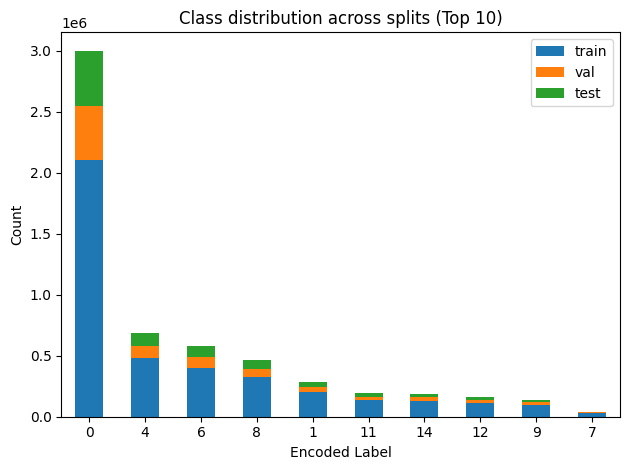

Saved plot: /opt/work/dataset/processed/splits_stratified/class_distribution_split_top10.png


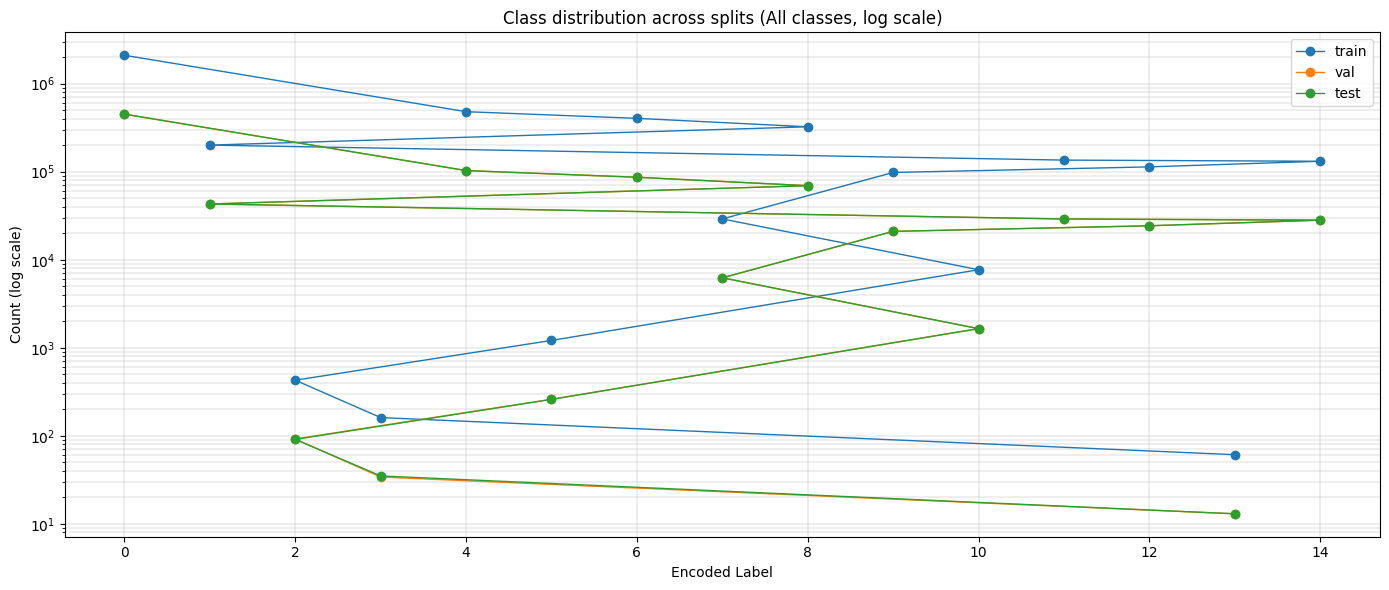

Saved plot: /opt/work/dataset/processed/splits_stratified/class_distribution_split_all.png


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.dataset as ds

SPLIT_DIR = "/opt/work/dataset/processed/splits_stratified"
OUT_PLOT1 = os.path.join(SPLIT_DIR, "class_distribution_split_top10.png")
OUT_PLOT2 = os.path.join(SPLIT_DIR, "class_distribution_split_all.png")

LABEL_COL = "Label"

def counts_from_parquet(path):
    d = ds.dataset(path, format="parquet")
    y = d.to_table(columns=[LABEL_COL]).column(LABEL_COL).to_pandas()
    return y.value_counts().sort_index()

train_path = os.path.join(SPLIT_DIR, "train.parquet")
val_path   = os.path.join(SPLIT_DIR, "val.parquet")
test_path  = os.path.join(SPLIT_DIR, "test.parquet")

train_c = counts_from_parquet(train_path)
val_c   = counts_from_parquet(val_path)
test_c  = counts_from_parquet(test_path)

dist = pd.DataFrame({
    "train": train_c,
    "val": val_c,
    "test": test_c
}).fillna(0).astype(int)

dist["total"] = dist.sum(axis=1)
dist = dist.sort_values("total", ascending=False)

# Save CSV for report / paper
csv_path = os.path.join(SPLIT_DIR, "class_distribution_by_split.csv")
dist.to_csv(csv_path)
print("Saved CSV:", csv_path)

# -------- Plot 1: Top-10 --------
topN = 10
top = dist.head(topN)[["train", "val", "test"]]

plt.figure(figsize=(12, 6))
top.plot(kind="bar", stacked=True)
plt.title(f"Class distribution across splits (Top {topN})")
plt.xlabel("Encoded Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_PLOT1, dpi=200)
plt.show()

print("Saved plot:", OUT_PLOT1)

# -------- Plot 2: All classes (non-stacked, log-ish visibility) --------
all_df = dist[["train", "val", "test"]].copy()

plt.figure(figsize=(14, 6))
plt.plot(all_df.index, all_df["train"], marker="o", linewidth=1, label="train")
plt.plot(all_df.index, all_df["val"], marker="o", linewidth=1, label="val")
plt.plot(all_df.index, all_df["test"], marker="o", linewidth=1, label="test")
plt.yscale("log")  # helps show tiny classes
plt.title("Class distribution across splits (All classes, log scale)")
plt.xlabel("Encoded Label")
plt.ylabel("Count (log scale)")
plt.grid(True, which="both", linewidth=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_PLOT2, dpi=200)
plt.show()

print("Saved plot:", OUT_PLOT2)

In [3]:
import pyarrow.dataset as ds
import pandas as pd
import numpy as np

TRAIN_PATH = "/opt/work/dataset/processed/splits_stratified/train.parquet"
LABEL_COL = "Label"
DROP_COLS = []

SAMPLE_PER_CLASS = 20000  # safe

dataset = ds.dataset(TRAIN_PATH, format="parquet")

samples = []

for label in range(15):
    table = (
        dataset
        .to_table(filter=(ds.field("Label") == label))
        .to_pandas()
    )
    
    if len(table) > SAMPLE_PER_CLASS:
        table = table.sample(SAMPLE_PER_CLASS, random_state=42)
    
    samples.append(table)
    print(f"Label {label}: sampled {len(table)}")

df_fs = pd.concat(samples, ignore_index=True)

X_fs = df_fs.drop(columns=[LABEL_COL] + DROP_COLS)
y_fs = df_fs[LABEL_COL]

print("Feature-selection sample shape:", X_fs.shape)

Label 0: sampled 20000
Label 1: sampled 20000
Label 2: sampled 428
Label 3: sampled 161
Label 4: sampled 20000
Label 5: sampled 1211
Label 6: sampled 20000
Label 7: sampled 20000
Label 8: sampled 20000
Label 9: sampled 20000
Label 10: sampled 7693
Label 11: sampled 20000
Label 12: sampled 20000
Label 13: sampled 61
Label 14: sampled 20000
Feature-selection sample shape: (209554, 71)


In [6]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    max_depth=None
)

rf.fit(X_fs, y_fs)

importances = pd.Series(
    rf.feature_importances_,
    index=X_fs.columns
).sort_values(ascending=False)

print("Top 30 important features:")
print(importances.head(30))

# Save full ranking
out_csv = "/opt/work/dataset/processed/rf_feature_importance_full.csv"
importances.reset_index().rename(columns={"index": "feature", 0: "importance"}).to_csv(out_csv, index=False)
print(f"\nSaved full importance ranking to: {out_csv}")

Top 30 important features:
Timestamp            0.194724
Init Fwd Win Byts    0.069939
Dst Port             0.061207
Fwd Seg Size Min     0.053485
Fwd Pkts/s           0.033779
Flow Pkts/s          0.031681
Flow Duration        0.031681
Fwd Header Len       0.028503
Flow IAT Max         0.026769
Flow IAT Mean        0.026448
Tot Fwd Pkts         0.024859
Subflow Fwd Pkts     0.023718
Fwd IAT Tot          0.022708
Fwd IAT Max          0.020101
Subflow Fwd Byts     0.018181
Bwd Pkts/s           0.017784
Fwd IAT Mean         0.016731
TotLen Fwd Pkts      0.016614
Fwd IAT Min          0.016238
Flow IAT Min         0.015548
Init Bwd Win Byts    0.013343
Fwd Act Data Pkts    0.013258
Fwd Pkt Len Mean     0.010061
Bwd Header Len       0.010056
Bwd IAT Mean         0.009862
Fwd Seg Size Avg     0.009541
Fwd Pkt Len Max      0.009469
Flow IAT Std         0.009430
Bwd Pkt Len Mean     0.008748
Bwd IAT Min          0.008685
dtype: float64

Saved full importance ranking to: /opt/work/dataset/proce